In [33]:
mask_folder=r'/mnt/efs/dl_jrc/student_data/S-DC/Masks_padded_final'

In [34]:
import os
import torch
import torchvision.transforms.v2 as transforms_v2
import tifffile
import matplotlib.pyplot as plt

In [35]:
mask_filenames=sorted(os.listdir(mask_folder))

In [36]:
from_np = transforms_v2.Lambda(lambda x: torch.from_numpy(x))

In [37]:
mask_path = os.path.join(mask_folder, mask_filenames[0])

In [38]:
mask = from_np(tifffile.imread(mask_path))

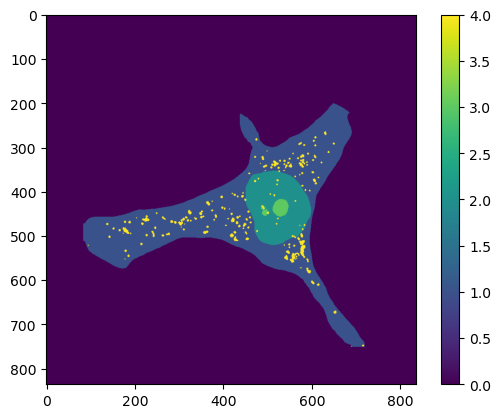

In [39]:
plt.imshow(mask)
plt.colorbar()

In [40]:
mask_torch=mask.to(torch.float32)

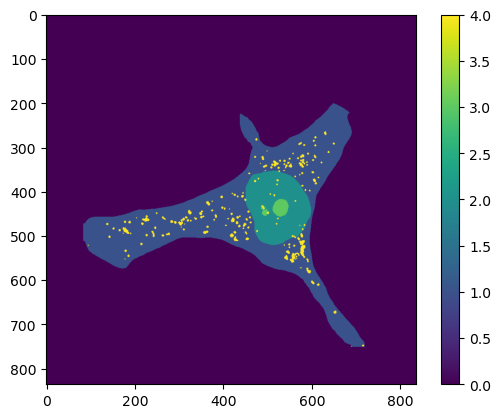

In [41]:
plt.imshow(mask_torch)
plt.colorbar()

In [57]:
transform = transforms_v2.Compose([
    transforms_v2.Resize((256,256),interpolation=transforms_v2.InterpolationMode.NEAREST,antialias=True),
    #transforms_v2.RandomRotation([-90,90],fill=0),
    transforms_v2.RandomHorizontalFlip(p=0.5),
    transforms_v2.RandomVerticalFlip(p=0.5),
    transforms_v2.RandomResizedCrop((192,192),antialias=True,scale=(0.75,1.25),interpolation=transforms_v2.InterpolationMode.NEAREST),
])

In [58]:
mask_unsqueeze=mask_torch.unsqueeze(dim=0)

In [59]:
mask_transform = transform(mask_unsqueeze)

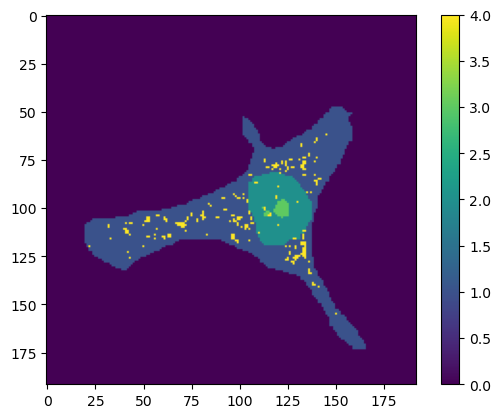

In [60]:
plt.imshow(mask_transform.squeeze())
plt.colorbar()